In [1]:
import pandas as pd

from pandas import json_normalize
from SPARQLWrapper import SPARQLWrapper, JSON
import matplotlib.pyplot as plt
import plotly.express as px

import os

In [3]:
#https://github.com/SuLab/sparql_to_pandas/blob/master/SPARQL_pandas.ipynb
def query_wikidata(sparql_query, sparql_service_url):
    """
    Query the endpoint with the given query string and return the results as a pandas Dataframe.
    """
    # create the connection to the endpoint
    # Wikidata enforces now a strict User-Agent policy, we need to specify the agent
    # See here https://www.wikidata.org/wiki/Wikidata:Project_chat/Archive/2019/07#problems_with_query_API
    # https://meta.wikimedia.org/wiki/User-Agent_policy
    sparql = SPARQLWrapper(sparql_service_url, agent="Sparql Wrapper on Jupyter example")  
    
    sparql.setQuery(sparql_query)
    sparql.setReturnFormat(JSON)

    # ask for the result
    result = sparql.query().convert()
    return json_normalize(result["results"]["bindings"])

## Simple Table

In [4]:
def simple_table(dataframe):
    table = dataframe.filter(regex='.value')
    table = table.rename(columns = lambda col: col.replace(".value", ""))
    
    return table

In [8]:
#clickable
def make_clickable(val):
    # target _blank to open new window
    return '<a target="_blank" href="{}">{}</a>'.format(val,val)

table = table.style.format({'item': make_clickable})

## LineChart

In [66]:
sparql_query = """
    #Population growth in Suriname from 1960 onward
    #defaultView:LineChart
    SELECT ?year ?population {
      wd:Q730 p:P1082 ?p .
      ?p pq:P585 ?year ;
         ps:P1082 ?population .
      SERVICE wikibase:label { bd:serviceParam wikibase:language "en" }
    }
    ORDER BY ?year
    """
#to query another endpoint, change the URL for the service and the query
sparql_service_url = "https://query.wikidata.org/sparql"
result_table = query_wikidata(sparql_query, sparql_service_url)

In [70]:
table = simple_table(result_table)
table.head(10)

In [73]:
fig = px.line(table, x="year", y="population", title='Population')
fig.show()

## ScatterChart

In [74]:
sparql_query = """
    #Gene and metabolite counts per pathway
    #Gene and metabolite counts per path
    #defaultView:ScatterChart
    SELECT ?path ?genes ?metabolites ?pathway WHERE {
      {SELECT DISTINCT ?path (COUNT(?pwPart) AS ?genes) WHERE {
          ?path wdt:P2410 ?WikipathsID.
          ?path wdt:P527 ?pwPart.
          ?pwPart wdt:P31 wd:Q7187.
          SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }
        }
        GROUP BY ?path ?genes
      }
      {SELECT DISTINCT ?path (COUNT(?pwPart) AS ?metabolites) WHERE {
          ?path wdt:P2410 ?WikipathsID.
          ?path wdt:P527 ?pwPart.
          ?pwPart wdt:P31 wd:Q11173.
          SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }
        }
        GROUP BY ?path ?metabolites
      }
      OPTIONAL { ?path rdfs:label ?pathway. }
    }
    ORDER BY DESC(?genes)
    """
#to query another endpoint, change the URL for the service and the query
sparql_service_url = "https://query.wikidata.org/sparql"
result_table = query_wikidata(sparql_query, sparql_service_url)

In [91]:
table = simple_table(result_table)

In [76]:
fig = px.scatter(table, x="genes", y="metabolites", color="pathway")
fig.show()

## BarChart

In [11]:
sparql_query = """
    #population of each province in indonesia
    #defaultView:BarChart
    SELECT DISTINCT ?itemLabel ?population
    WHERE
    {
      ?item wdt:P31 wd:Q5098;
            wdt:P1082 ?population .
      SERVICE wikibase:label { bd:serviceParam wikibase:language "[AUTO_LANGUAGE],en" }
    }
    """
#to query another endpoint, change the URL for the service and the query
sparql_service_url = "https://query.wikidata.org/sparql"
result_table = query_wikidata(sparql_query, sparql_service_url)

In [71]:
table = simple_table(result_table)
table.head()

In [41]:
table['population']  = table['population'].astype('int')
fig = px.bar(table, y='population', x='itemLabel')
fig.show()

## BubbleChart

In [42]:
sparql_query = """
    #Return a bubble chart of mediatypes by count of file formats
    SELECT DISTINCT ?mediaType (COUNT (?ff) as ?count)
    WHERE
    {
      ?ff wdt:P31/wdt:P279* wd:Q235557.
      ?ff wdt:P1163 ?mediaType.
      SERVICE wikibase:label { bd:serviceParam wikibase:language "en" }
    }

    GROUP BY ?mediaType 
    ORDER BY DESC (?count)
    """
#to query another endpoint, change the URL for the service and the query
sparql_service_url = "https://query.wikidata.org/sparql"
result_table = query_wikidata(sparql_query, sparql_service_url)

In [60]:
table = simple_table(result_table)
table['count']  = table['count'].astype('int')

In [72]:
fig = px.scatter(table, x='count', y='count',
                 size='count', color='mediaType',
                 hover_name='mediaType', log_x=True, size_max=60)
fig.show()

In [63]:
# source: https://matplotlib.org/devdocs/gallery/misc/packed_bubbles.html
class BubbleChart:
    def __init__(self, area, bubble_spacing=0):
        """
        Setup for bubble collapse.

        Parameters
        ----------
        area : array-like
            Area of the bubbles.
        bubble_spacing : float, default: 0
            Minimal spacing between bubbles after collapsing.

        Notes
        -----
        If "area" is sorted, the results might look weird.
        """
        area = np.asarray(area)
        r = np.sqrt(area / np.pi)

        self.bubble_spacing = bubble_spacing
        self.bubbles = np.ones((len(area), 4))
        self.bubbles[:, 2] = r
        self.bubbles[:, 3] = area
        self.maxstep = 2 * self.bubbles[:, 2].max() + self.bubble_spacing
        self.step_dist = self.maxstep / 2

        # calculate initial grid layout for bubbles
        length = np.ceil(np.sqrt(len(self.bubbles)))
        grid = np.arange(length) * self.maxstep
        gx, gy = np.meshgrid(grid, grid)
        self.bubbles[:, 0] = gx.flatten()[:len(self.bubbles)]
        self.bubbles[:, 1] = gy.flatten()[:len(self.bubbles)]

        self.com = self.center_of_mass()

    def center_of_mass(self):
        return np.average(
            self.bubbles[:, :2], axis=0, weights=self.bubbles[:, 3]
        )

    def center_distance(self, bubble, bubbles):
        return np.hypot(bubble[0] - bubbles[:, 0],
                        bubble[1] - bubbles[:, 1])

    def outline_distance(self, bubble, bubbles):
        center_distance = self.center_distance(bubble, bubbles)
        return center_distance - bubble[2] - \
            bubbles[:, 2] - self.bubble_spacing

    def check_collisions(self, bubble, bubbles):
        distance = self.outline_distance(bubble, bubbles)
        return len(distance[distance < 0])

    def collides_with(self, bubble, bubbles):
        distance = self.outline_distance(bubble, bubbles)
        idx_min = np.argmin(distance)
        return idx_min if type(idx_min) == np.ndarray else [idx_min]

    def collapse(self, n_iterations=50):
        """
        Move bubbles to the center of mass.

        Parameters
        ----------
        n_iterations : int, default: 50
            Number of moves to perform.
        """
        for _i in range(n_iterations):
            moves = 0
            for i in range(len(self.bubbles)):
                rest_bub = np.delete(self.bubbles, i, 0)
                # try to move directly towards the center of mass
                # direction vector from bubble to the center of mass
                dir_vec = self.com - self.bubbles[i, :2]

                # shorten direction vector to have length of 1
                dir_vec = dir_vec / np.sqrt(dir_vec.dot(dir_vec))

                # calculate new bubble position
                new_point = self.bubbles[i, :2] + dir_vec * self.step_dist
                new_bubble = np.append(new_point, self.bubbles[i, 2:4])

                # check whether new bubble collides with other bubbles
                if not self.check_collisions(new_bubble, rest_bub):
                    self.bubbles[i, :] = new_bubble
                    self.com = self.center_of_mass()
                    moves += 1
                else:
                    # try to move around a bubble that you collide with
                    # find colliding bubble
                    for colliding in self.collides_with(new_bubble, rest_bub):
                        # calculate direction vector
                        dir_vec = rest_bub[colliding, :2] - self.bubbles[i, :2]
                        dir_vec = dir_vec / np.sqrt(dir_vec.dot(dir_vec))
                        # calculate orthogonal vector
                        orth = np.array([dir_vec[1], -dir_vec[0]])
                        # test which direction to go
                        new_point1 = (self.bubbles[i, :2] + orth *
                                      self.step_dist)
                        new_point2 = (self.bubbles[i, :2] - orth *
                                      self.step_dist)
                        dist1 = self.center_distance(
                            self.com, np.array([new_point1]))
                        dist2 = self.center_distance(
                            self.com, np.array([new_point2]))
                        new_point = new_point1 if dist1 < dist2 else new_point2
                        new_bubble = np.append(new_point, self.bubbles[i, 2:4])
                        if not self.check_collisions(new_bubble, rest_bub):
                            self.bubbles[i, :] = new_bubble
                            self.com = self.center_of_mass()

            if moves / len(self.bubbles) < 0.1:
                self.step_dist = self.step_dist / 2

    def plot(self, ax, labels):
        """
        Draw the bubble plot.

        Parameters
        ----------
        ax : matplotlib.axes.Axes
        labels : list
            Labels of the bubbles.
        colors : list
            Colors of the bubbles.
        """
        for i in range(len(self.bubbles)):
            circ = plt.Circle(
                self.bubbles[i, :2], self.bubbles[i, 2]) #, color=colors[i]
            ax.add_patch(circ)
            ax.text(*self.bubbles[i, :2], labels[i],
                    horizontalalignment='center', verticalalignment='center')

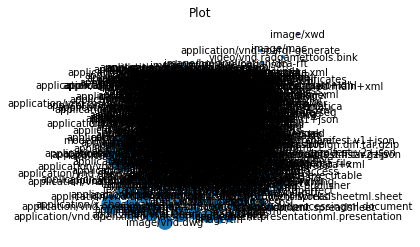

In [65]:
bubble_chart = BubbleChart(area=table['count'],
                           bubble_spacing=0.1)

bubble_chart.collapse()

fig, ax = plt.subplots(subplot_kw=dict(aspect="equal"))
bubble_chart.plot(
    ax, table['mediaType'])
ax.axis("off")
ax.relim()
ax.autoscale_view()
ax.set_title('Plot')

plt.show()

## AreaChart

In [86]:
sparql_query = """
    #defaultView:AreaChart
    SELECT ?cid (str(SAMPLE(?year_)) AS ?year )  (COUNT(*) AS ?count)  ?cause WHERE {
      ?pid wdt:P31 wd:Q5.
      ?pid wdt:P509 ?cid.
      ?cid wdt:P279* wd:Q12078.

      OPTIONAL {
        ?cid rdfs:label ?cause.
        FILTER((LANG(?cause)) = "en")
      }
       ?pid wdt:P570 ?_date_of_death. 
      BIND ( YEAR(?_date_of_death) AS ?year_ )
      FILTER( BOUND(?cause)  )
      FILTER( BOUND(?year_)  )
      FILTER( ?year_ > 1960 )
    }
    GROUP BY ?cid ?cause ?year_
    """
#to query another endpoint, change the URL for the service and the query
sparql_service_url = "https://query.wikidata.org/sparql"
result_table = query_wikidata(sparql_query, sparql_service_url)

In [89]:
table = simple_table(result_table)
table['count']  = table['count'].astype('int')

In [75]:
table.head()

,cid,cause,year,count
0,http://www.wikidata.org/entity/Q124292,cholangiocarcinoma,2018,9
1,http://www.wikidata.org/entity/Q124292,cholangiocarcinoma,2020,3
2,http://www.wikidata.org/entity/Q124292,cholangiocarcinoma,2019,4
3,http://www.wikidata.org/entity/Q124292,cholangiocarcinoma,1995,1
4,http://www.wikidata.org/entity/Q124292,cholangiocarcinoma,2016,3


In [90]:
fig = px.area(table, x="year", y="count", color="cause",
              line_group="cid")
fig.show()